Dataset loaded successfully!
Original Shape: (500, 6)

FIRST 5 RECORDS:
   Area  Bedrooms  Bathrooms  Age       Location     Price
0  1922         3          4    5     Vijayawada   7471000
1  2920         4          4    8      Bengaluru  19180000
2  2318         4          4   15        Chennai  12780000
3  1325         3          3    3  Visakhapatnam   6736000
4  1116         2          2    2      Hyderabad   5815000

DATASET INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Area       500 non-null    int64
 1   Bedrooms   500 non-null    int64
 2   Bathrooms  500 non-null    int64
 3   Age        500 non-null    int64
 4   Location   500 non-null    str  
 5   Price      500 non-null    int64
dtypes: int64(5), str(1)
memory usage: 23.6 KB
None

DATASET SHAPE:
(500, 6)

COLUMN NAMES:
['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Location', 'Price']



C:\Users\srikr\AppData\Local\Temp\ipykernel_7324\801624745.py:47: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


              Area    Bedrooms   Bathrooms         Age         Price
count   500.000000  500.000000  500.000000  500.000000  5.000000e+02
mean   1711.646000    2.680000    2.518000   15.276000  9.066560e+06
std     640.581769    1.120764    1.071435    8.980932  4.000079e+06
min     550.000000    1.000000    1.000000    0.000000  1.800000e+06
25%    1276.750000    2.000000    2.000000    7.000000  6.213750e+06
50%    1679.000000    3.000000    3.000000   16.000000  8.426000e+06
75%    2129.750000    3.000000    3.000000   23.000000  1.147900e+07
max    3701.000000    5.000000    4.000000   30.000000  2.179100e+07

MOST EXPENSIVE PROPERTY:
Area              3176
Bedrooms             5
Bathrooms            4
Age                  2
Location     Bengaluru
Price         21791000
Name: 197, dtype: object

CHEAPEST PROPERTY:
Area                550
Bedrooms              1
Bathrooms             1
Age                   7
Location     Vijayawada
Price           1800000
Name: 180, dtype: object


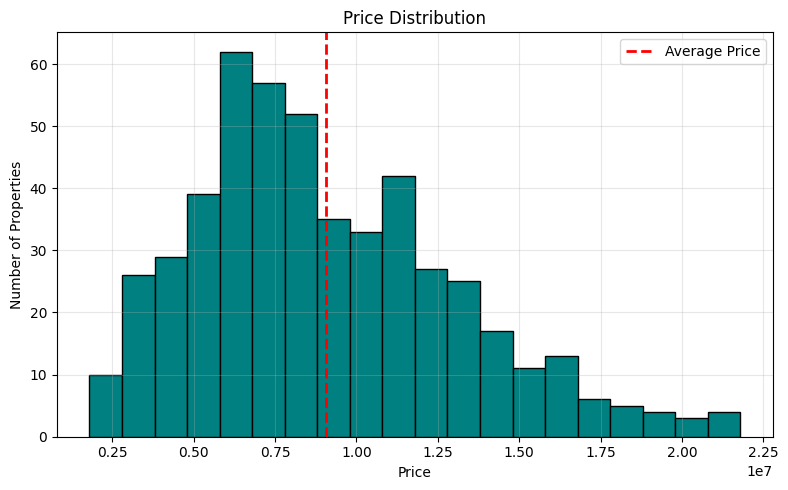

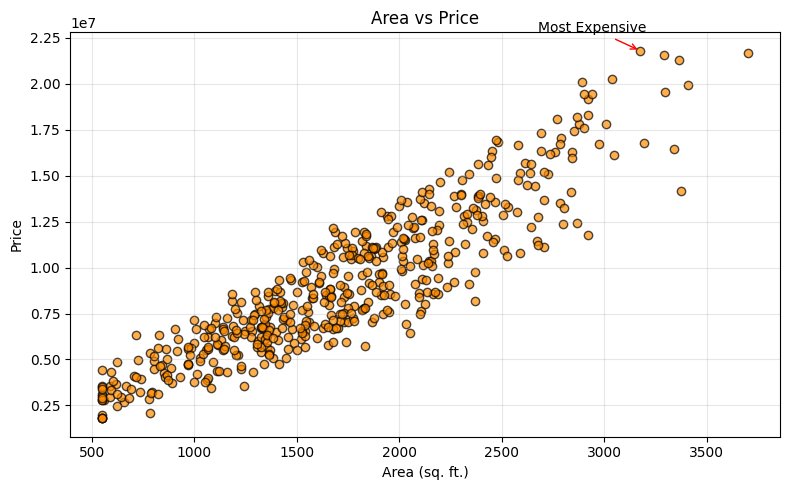

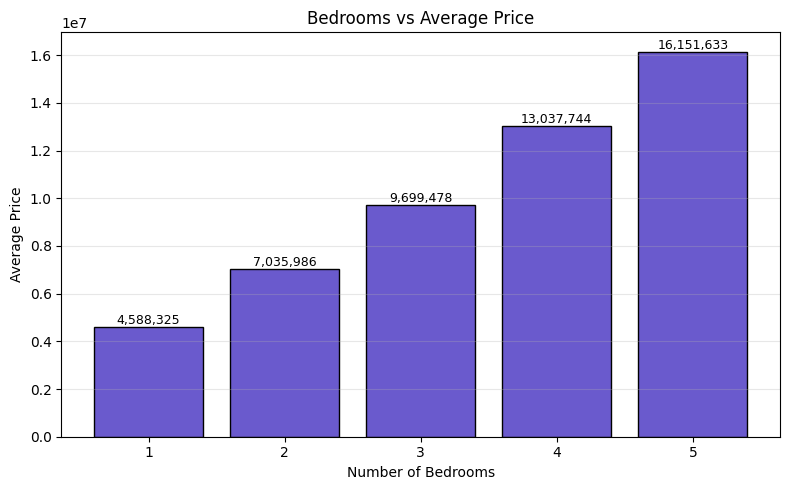

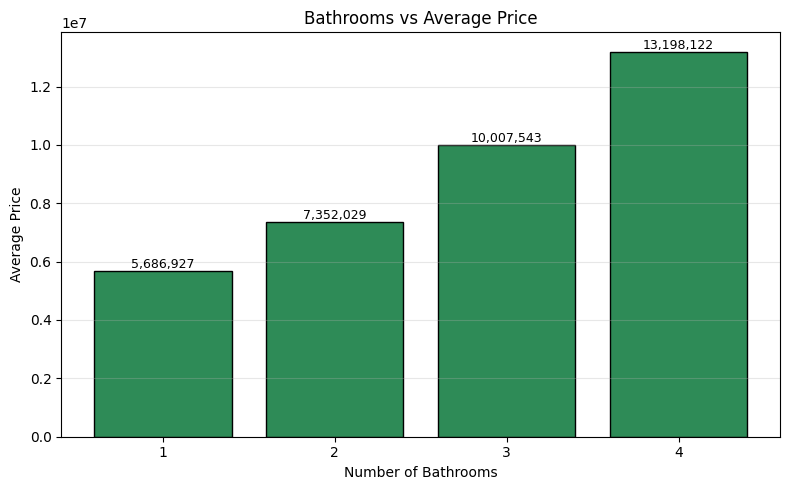

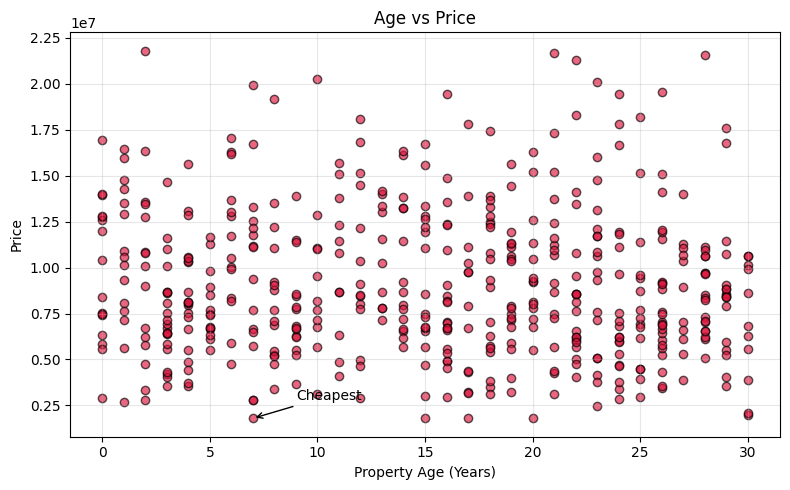

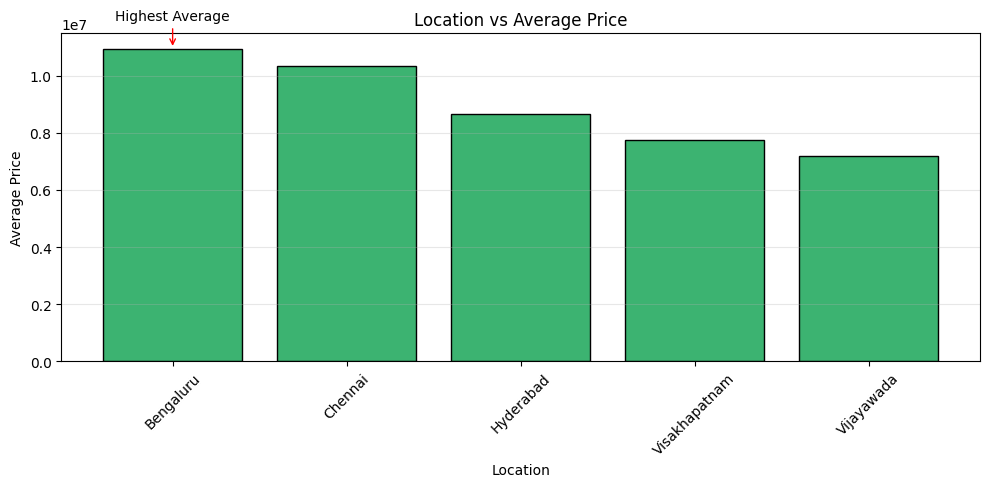

C:\Users\srikr\AppData\Local\Temp\ipykernel_7324\801624745.py:318: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


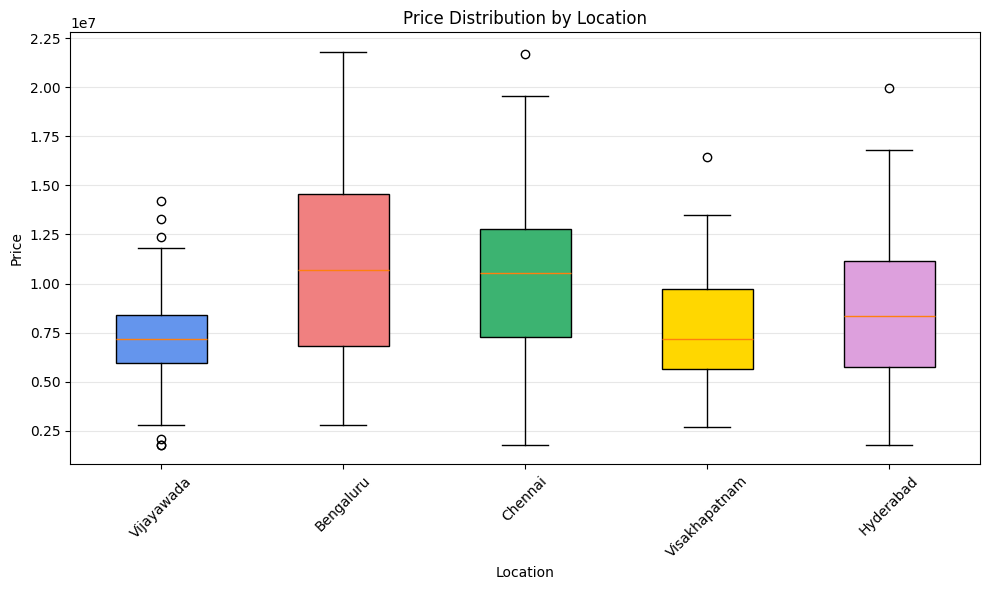

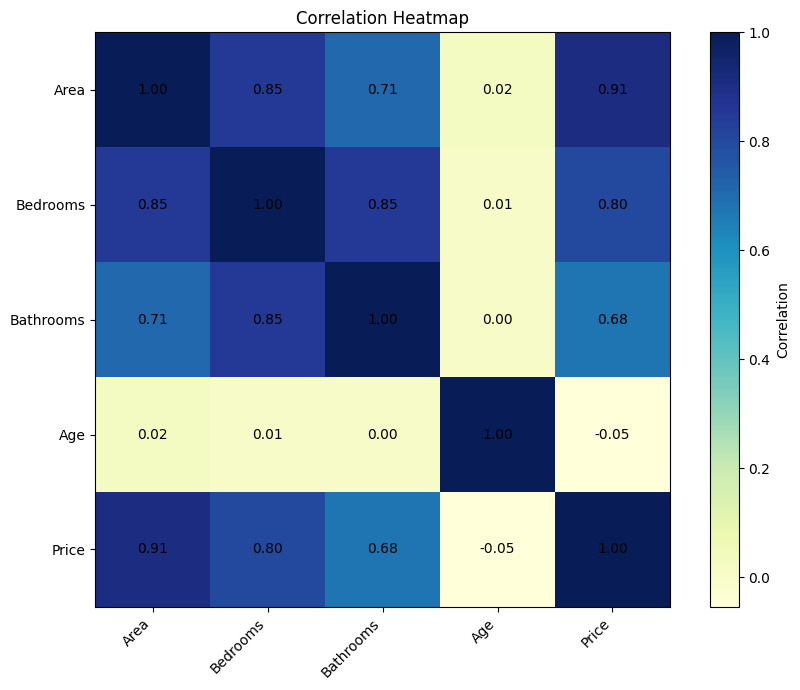

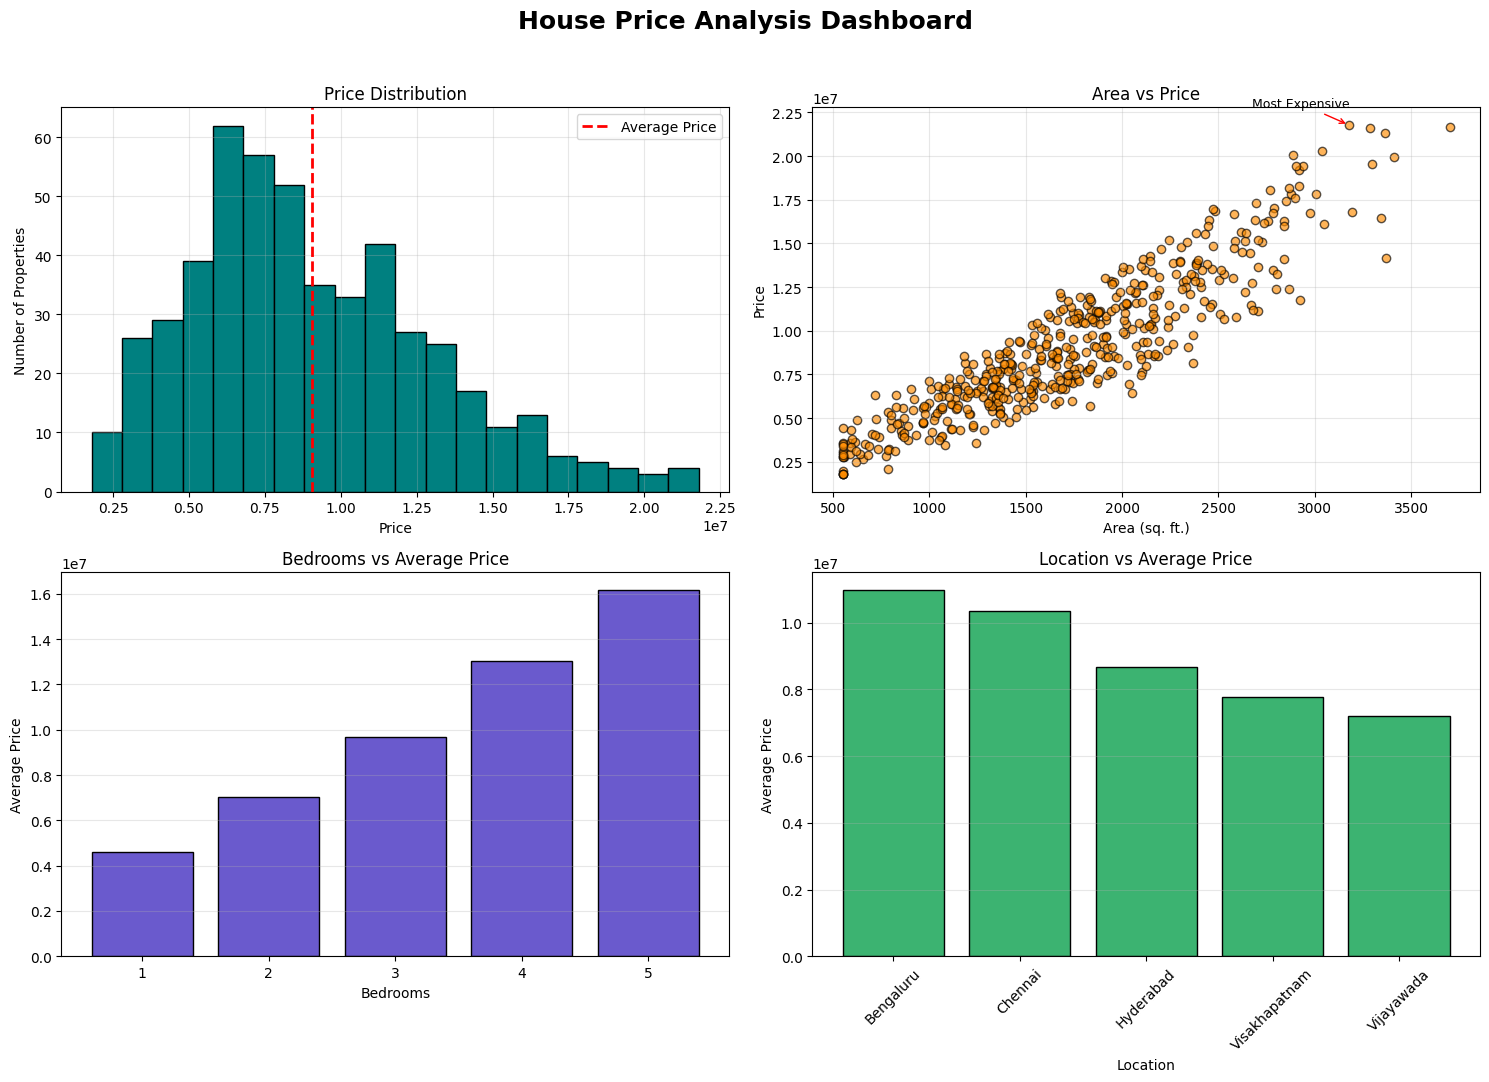


PROPERTY SUMMARY

Most Expensive Property:
Location: Bengaluru
Area: 3176
Bedrooms: 5
Bathrooms: 4
Age: 2
Price: 21,791,000

Cheapest Property:
Location: Vijayawada
Area: 550
Bedrooms: 1
Bathrooms: 1
Age: 7
Price: 1,800,000

BUSINESS / TECHNICAL INSIGHTS

1. Area and Price have a correlation of 0.91,
   indicating a strong relationship between property size and price.

2. Properties with more bedrooms generally show differences
   in their average prices, which can help understand the
   pricing impact of property size and capacity.

3. Properties with different numbers of bathrooms also show
   differences in their average prices, indicating that
   bathroom count can be associated with property value.

4. Age and Price have a correlation of -0.05.
   The Age vs Price graph helps identify how property age
   is associated with market price.

5. Bengaluru has the highest average property
   price among the locations in the dataset.

6. Vijayawada has the lowest average property
   pri

In [1]:
# ================================================================
#              HOUSE PRICE DATA ANALYSIS
#              Using Pandas and Matplotlib
# ================================================================

# ------------------------------------------------
# 1. IMPORT REQUIRED LIBRARIES
# ------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# 2. LOAD THE CSV DATASET
# ------------------------------------------------
df = pd.read_csv("house_prices_500.csv")

print("Dataset loaded successfully!")
print("Original Shape:", df.shape)


# ------------------------------------------------
# 3. INSPECT THE DATASET
# ------------------------------------------------
print("\nFIRST 5 RECORDS:")
print(df.head())

print("\nDATASET INFORMATION:")
print(df.info())

print("\nDATASET SHAPE:")
print(df.shape)

print("\nCOLUMN NAMES:")
print(df.columns.tolist())


# ------------------------------------------------
# 4. CHECK AND HANDLE MISSING VALUES
# ------------------------------------------------
print("\nMISSING VALUES BEFORE HANDLING:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

# Fill missing numerical values with median
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing categorical values with mode
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("\nMISSING VALUES AFTER HANDLING:")
print(df.isnull().sum())


# ------------------------------------------------
# 5. REMOVE DUPLICATE RECORDS
# ------------------------------------------------
duplicates = df.duplicated().sum()

print("\nNUMBER OF DUPLICATE RECORDS:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# ------------------------------------------------
# 6. IDENTIFY NUMERICAL AND CATEGORICAL COLUMNS
# ------------------------------------------------
print("\nNUMERICAL COLUMNS:")
print(numerical_columns)

print("\nCATEGORICAL COLUMNS:")
print(categorical_columns)


# ------------------------------------------------
# 7. BASIC STATISTICAL ANALYSIS
# ------------------------------------------------
print("\nBASIC STATISTICAL ANALYSIS:")
print(df[numerical_columns].describe())


# ------------------------------------------------
# 8. IMPORTANT PROPERTY INFORMATION
# ------------------------------------------------
most_expensive = df.loc[df["Price"].idxmax()]
cheapest = df.loc[df["Price"].idxmin()]

print("\nMOST EXPENSIVE PROPERTY:")
print(most_expensive)

print("\nCHEAPEST PROPERTY:")
print(cheapest)


# ================================================================
#                    VISUALIZATIONS
# ================================================================

# ------------------------------------------------
# 9. PRICE DISTRIBUTION - HISTOGRAM
# ------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    df["Price"],
    bins=20,
    color="teal",
    edgecolor="black"
)

plt.axvline(
    df["Price"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Average Price"
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 10. AREA VS PRICE - SCATTER PLOT
# ------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area"],
    df["Price"],
    color="darkorange",
    alpha=0.7,
    edgecolors="black"
)

# Annotate the most expensive property
plt.annotate(
    "Most Expensive",
    xy=(most_expensive["Area"], most_expensive["Price"]),
    xytext=(most_expensive["Area"] - 500, most_expensive["Price"] + 1000000),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10
)

plt.title("Area vs Price")
plt.xlabel("Area (sq. ft.)")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 11. BEDROOMS VS AVERAGE PRICE - BAR CHART
# ------------------------------------------------
bedroom_avg = df.groupby("Bedrooms")["Price"].mean()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    bedroom_avg.index.astype(str),
    bedroom_avg.values,
    color="slateblue",
    edgecolor="black"
)

plt.title("Bedrooms vs Average Price")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.grid(axis="y", alpha=0.3)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 12. BATHROOMS VS AVERAGE PRICE - BAR CHART
# ------------------------------------------------
bathroom_avg = df.groupby("Bathrooms")["Price"].mean()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    bathroom_avg.index.astype(str),
    bathroom_avg.values,
    color="seagreen",
    edgecolor="black"
)

plt.title("Bathrooms vs Average Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Price")
plt.grid(axis="y", alpha=0.3)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 13. AGE VS PRICE - SCATTER PLOT
# ------------------------------------------------
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Age"],
    df["Price"],
    color="crimson",
    alpha=0.65,
    edgecolors="black"
)

# Annotate cheapest property
plt.annotate(
    "Cheapest",
    xy=(cheapest["Age"], cheapest["Price"]),
    xytext=(cheapest["Age"] + 2, cheapest["Price"] + 1000000),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.title("Age vs Price")
plt.xlabel("Property Age (Years)")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 14. LOCATION VS AVERAGE PRICE - BAR CHART
# ------------------------------------------------
location_avg = df.groupby("Location")["Price"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    location_avg.index,
    location_avg.values,
    color="mediumseagreen",
    edgecolor="black"
)

plt.title("Location vs Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

# Annotate highest average-price location
highest_location = location_avg.idxmax()
highest_value = location_avg.max()

plt.annotate(
    "Highest Average",
    xy=(list(location_avg.index).index(highest_location), highest_value),
    xytext=(list(location_avg.index).index(highest_location), highest_value + 1000000),
    ha="center",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10
)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 15. BOX PLOT OF PRICE BY LOCATION
# ------------------------------------------------
locations = df["Location"].unique()

price_by_location = [
    df[df["Location"] == location]["Price"]
    for location in locations
]

plt.figure(figsize=(10, 6))

box = plt.boxplot(
    price_by_location,
    labels=locations,
    patch_artist=True
)

# Different colors for each location
box_colors = [
    "cornflowerblue",
    "lightcoral",
    "mediumseagreen",
    "gold",
    "plum"
]

for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)

plt.title("Price Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# 16. HEATMAP-STYLE VISUALIZATION
# ------------------------------------------------
correlation = df[numerical_columns].corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation,
    cmap="YlGnBu",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

# Add correlation values inside cells
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.tight_layout()
plt.show()


# ================================================================
#                 2 × 2 MATPLOTLIB DASHBOARD
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ------------------------------------------------
# Dashboard 1: Price Distribution
# ------------------------------------------------
axes[0, 0].hist(
    df["Price"],
    bins=20,
    color="teal",
    edgecolor="black"
)

axes[0, 0].axvline(
    df["Price"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Average Price"
)

axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Number of Properties")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)


# ------------------------------------------------
# Dashboard 2: Area vs Price
# ------------------------------------------------
axes[0, 1].scatter(
    df["Area"],
    df["Price"],
    color="darkorange",
    alpha=0.65,
    edgecolors="black"
)

axes[0, 1].annotate(
    "Most Expensive",
    xy=(most_expensive["Area"], most_expensive["Price"]),
    xytext=(
        most_expensive["Area"] - 500,
        most_expensive["Price"] + 1000000
    ),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9
)

axes[0, 1].set_title("Area vs Price")
axes[0, 1].set_xlabel("Area (sq. ft.)")
axes[0, 1].set_ylabel("Price")
axes[0, 1].grid(True, alpha=0.3)


# ------------------------------------------------
# Dashboard 3: Bedrooms vs Average Price
# ------------------------------------------------
axes[1, 0].bar(
    bedroom_avg.index.astype(str),
    bedroom_avg.values,
    color="slateblue",
    edgecolor="black"
)

axes[1, 0].set_title("Bedrooms vs Average Price")
axes[1, 0].set_xlabel("Bedrooms")
axes[1, 0].set_ylabel("Average Price")
axes[1, 0].grid(axis="y", alpha=0.3)


# ------------------------------------------------
# Dashboard 4: Location vs Average Price
# ------------------------------------------------
axes[1, 1].bar(
    location_avg.index,
    location_avg.values,
    color="mediumseagreen",
    edgecolor="black"
)

axes[1, 1].set_title("Location vs Average Price")
axes[1, 1].set_xlabel("Location")
axes[1, 1].set_ylabel("Average Price")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.suptitle(
    "House Price Analysis Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# ================================================================
#                 FINAL PROPERTY SUMMARY
# ================================================================

print("\n" + "=" * 60)
print("PROPERTY SUMMARY")
print("=" * 60)

print("\nMost Expensive Property:")
print("Location:", most_expensive["Location"])
print("Area:", most_expensive["Area"])
print("Bedrooms:", most_expensive["Bedrooms"])
print("Bathrooms:", most_expensive["Bathrooms"])
print("Age:", most_expensive["Age"])
print("Price:", f"{most_expensive['Price']:,}")

print("\nCheapest Property:")
print("Location:", cheapest["Location"])
print("Area:", cheapest["Area"])
print("Bedrooms:", cheapest["Bedrooms"])
print("Bathrooms:", cheapest["Bathrooms"])
print("Age:", cheapest["Age"])
print("Price:", f"{cheapest['Price']:,}")


# ================================================================
#                 5–7 BUSINESS / TECHNICAL INSIGHTS
# ================================================================

area_price_corr = df["Area"].corr(df["Price"])
age_price_corr = df["Age"].corr(df["Price"])

highest_avg_location = location_avg.idxmax()
lowest_avg_location = location_avg.idxmin()

print("\n" + "=" * 60)
print("BUSINESS / TECHNICAL INSIGHTS")
print("=" * 60)

print(f"""
1. Area and Price have a correlation of {area_price_corr:.2f},
   indicating a strong relationship between property size and price.

2. Properties with more bedrooms generally show differences
   in their average prices, which can help understand the
   pricing impact of property size and capacity.

3. Properties with different numbers of bathrooms also show
   differences in their average prices, indicating that
   bathroom count can be associated with property value.

4. Age and Price have a correlation of {age_price_corr:.2f}.
   The Age vs Price graph helps identify how property age
   is associated with market price.

5. {highest_avg_location} has the highest average property
   price among the locations in the dataset.

6. {lowest_avg_location} has the lowest average property
   price among the locations in the dataset.

7. The price-by-location box plot shows the spread,
   median, and possible variation in property prices across
   different locations, helping identify differences in
   local property markets.
""")

C:\Users\srikr\AppData\Local\Temp\ipykernel_3916\2744513119.py:202: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1, 2].boxplot(


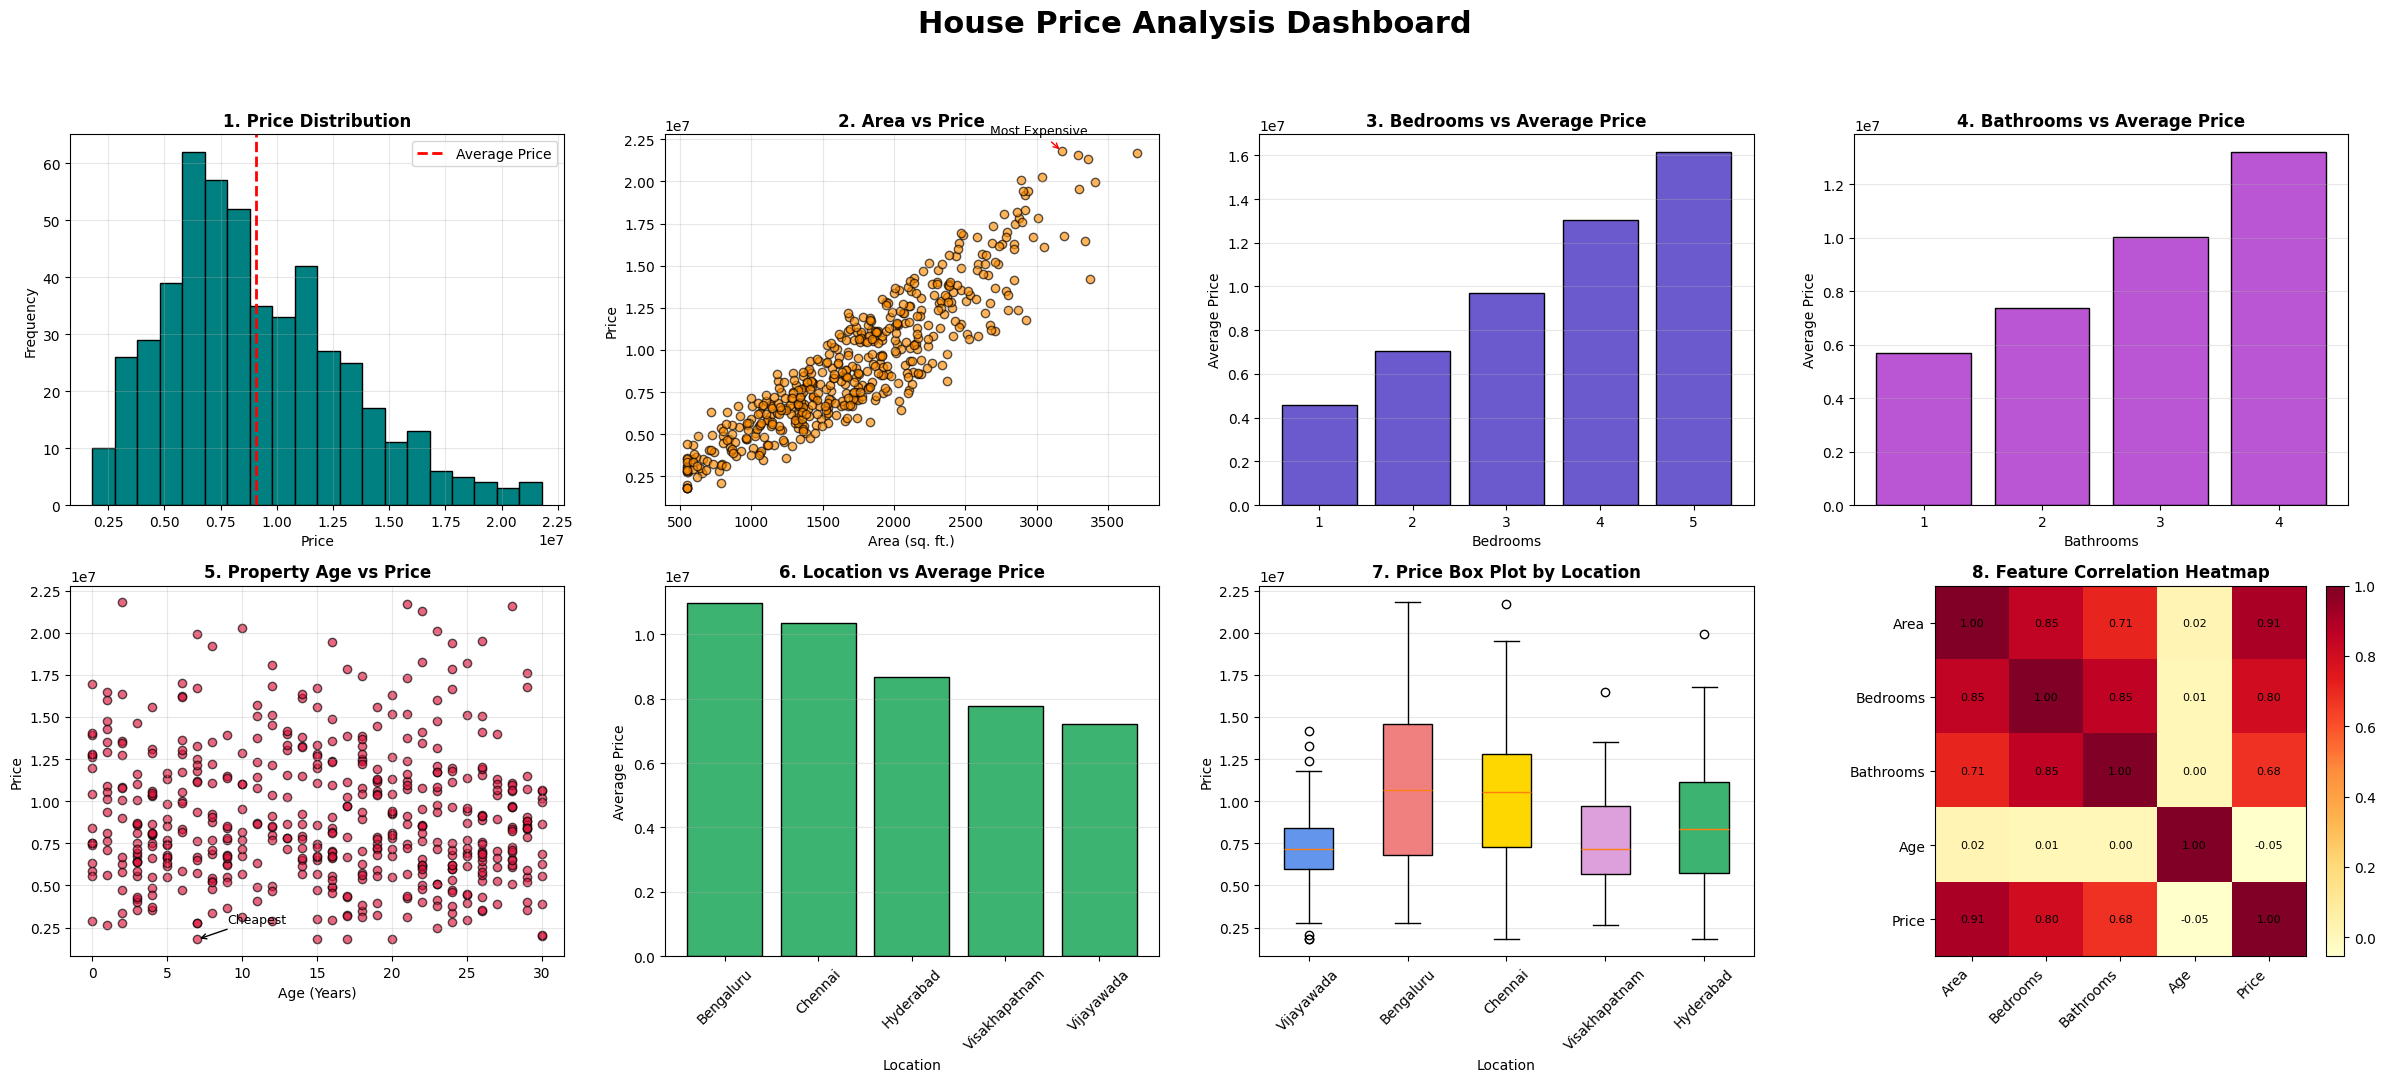

In [ ]:
# ============================================================
#      ALL 8 VISUALIZATIONS - SINGLE PAGE DASHBOARD
#      Independent code - paste at the bottom
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# LOAD DATASET
# ------------------------------------------------------------
df = pd.read_csv("house_prices_500.csv")

# Numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

# Find most expensive and cheapest properties
most_expensive = df.loc[df["Price"].idxmax()]
cheapest = df.loc[df["Price"].idxmin()]


# ============================================================
# CREATE 2 × 4 DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 11))

fig.suptitle(
    "House Price Analysis Dashboard",
    fontsize=22,
    fontweight="bold"
)


# ------------------------------------------------------------
# 1. PRICE DISTRIBUTION
# ------------------------------------------------------------
axes[0, 0].hist(
    df["Price"],
    bins=20,
    color="teal",
    edgecolor="black"
)

axes[0, 0].axvline(
    df["Price"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label="Average Price"
)

axes[0, 0].set_title("1. Price Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Price")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 2. AREA VS PRICE
# ------------------------------------------------------------
axes[0, 1].scatter(
    df["Area"],
    df["Price"],
    color="darkorange",
    edgecolors="black",
    alpha=0.65
)

axes[0, 1].annotate(
    "Most Expensive",
    xy=(most_expensive["Area"], most_expensive["Price"]),
    xytext=(
        most_expensive["Area"] - 500,
        most_expensive["Price"] + 1000000
    ),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9
)

axes[0, 1].set_title("2. Area vs Price", fontweight="bold")
axes[0, 1].set_xlabel("Area (sq. ft.)")
axes[0, 1].set_ylabel("Price")
axes[0, 1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 3. BEDROOMS VS AVERAGE PRICE
# ------------------------------------------------------------
bedroom_avg = df.groupby("Bedrooms")["Price"].mean()

axes[0, 2].bar(
    bedroom_avg.index.astype(str),
    bedroom_avg.values,
    color="slateblue",
    edgecolor="black"
)

axes[0, 2].set_title(
    "3. Bedrooms vs Average Price",
    fontweight="bold"
)

axes[0, 2].set_xlabel("Bedrooms")
axes[0, 2].set_ylabel("Average Price")
axes[0, 2].grid(axis="y", alpha=0.3)


# ------------------------------------------------------------
# 4. BATHROOMS VS AVERAGE PRICE
# ------------------------------------------------------------
bathroom_avg = df.groupby("Bathrooms")["Price"].mean()

axes[0, 3].bar(
    bathroom_avg.index.astype(str),
    bathroom_avg.values,
    color="mediumorchid",
    edgecolor="black"
)

axes[0, 3].set_title(
    "4. Bathrooms vs Average Price",
    fontweight="bold"
)

axes[0, 3].set_xlabel("Bathrooms")
axes[0, 3].set_ylabel("Average Price")
axes[0, 3].grid(axis="y", alpha=0.3)


# ------------------------------------------------------------
# 5. AGE VS PRICE
# ------------------------------------------------------------
axes[1, 0].scatter(
    df["Age"],
    df["Price"],
    color="crimson",
    edgecolors="black",
    alpha=0.65
)

axes[1, 0].annotate(
    "Cheapest",
    xy=(cheapest["Age"], cheapest["Price"]),
    xytext=(
        cheapest["Age"] + 2,
        cheapest["Price"] + 1000000
    ),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9
)

axes[1, 0].set_title(
    "5. Property Age vs Price",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Age (Years)")
axes[1, 0].set_ylabel("Price")
axes[1, 0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 6. LOCATION VS AVERAGE PRICE
# ------------------------------------------------------------
location_avg = (
    df.groupby("Location")["Price"]
    .mean()
    .sort_values(ascending=False)
)

axes[1, 1].bar(
    location_avg.index,
    location_avg.values,
    color="mediumseagreen",
    edgecolor="black"
)

axes[1, 1].set_title(
    "6. Location vs Average Price",
    fontweight="bold"
)

axes[1, 1].set_xlabel("Location")
axes[1, 1].set_ylabel("Average Price")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(axis="y", alpha=0.3)


# ------------------------------------------------------------
# 7. PRICE BOX PLOT BY LOCATION
# ------------------------------------------------------------
locations = df["Location"].unique()

price_by_location = [
    df[df["Location"] == location]["Price"]
    for location in locations
]

box = axes[1, 2].boxplot(
    price_by_location,
    labels=locations,
    patch_artist=True
)

box_colors = [
    "cornflowerblue",
    "lightcoral",
    "gold",
    "plum",
    "mediumseagreen"
]

for patch, color in zip(box["boxes"], box_colors):
    patch.set_facecolor(color)

axes[1, 2].set_title(
    "7. Price Box Plot by Location",
    fontweight="bold"
)

axes[1, 2].set_xlabel("Location")
axes[1, 2].set_ylabel("Price")
axes[1, 2].tick_params(axis="x", rotation=45)
axes[1, 2].grid(axis="y", alpha=0.3)


# ------------------------------------------------------------
# 8. CORRELATION HEATMAP
# ------------------------------------------------------------
correlation = df[numerical_columns].corr()

im = axes[1, 3].imshow(
    correlation,
    cmap="Purples",
    interpolation="nearest"
)

axes[1, 3].set_title(
    "8. Feature Correlation Heatmap",
    fontweight="bold"
)

axes[1, 3].set_xticks(range(len(correlation.columns)))
axes[1, 3].set_xticklabels(
    correlation.columns,
    rotation=45,
    ha="right"
)

axes[1, 3].set_yticks(range(len(correlation.columns)))
axes[1, 3].set_yticklabels(correlation.columns)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        axes[1, 3].text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(
    im,
    ax=axes[1, 3],
    fraction=0.046,
    pad=0.04
)


# ------------------------------------------------------------
# FINAL FORMATTING AND SAVE
# ------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.savefig(
    "All_8_House_Price_Visualizations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Key Business / Technical Insights
# Area vs Price: Larger properties generally tend to have higher prices, showing a positive relationship between property size and price.
# Bedrooms vs Price: Average property price varies with the number of bedrooms, indicating that bedroom count influences property value.
# Bathrooms vs Price: Properties with more bathrooms generally have different—and often higher—average prices, suggesting bathrooms contribute to property value.
# Age vs Price: Property age shows a relationship with price; newer and older properties have noticeable differences in their price levels.
# Location vs Price: Average property prices vary significantly across locations, showing that location is an important factor in property valuation.
# Box Plot: The box plot shows differences in median prices, price spread, and possible outliers among locations, indicating variation in local property markets.
# Correlation Heatmap: The heatmap helps identify relationships between numerical features. Area and Price show a strong positive correlation, while other features show varying degrees of relationship with price.
# Short version for submission

# Overall, property price is influenced by factors such as area, bedrooms, bathrooms, age, and location. Larger properties generally have higher prices, while location creates noticeable differences in average property value. The box plot shows variation and outliers across locations, and the correlation heatmap highlights the strength of relationships between numerical features.